Mounted at /content/drive

[전체 데이터 크기]
(70, 26)

[진단 분포 상위 15개]
diagnosis_group
Dermatographia                                          17
Atopic Dermatitis                                       16
Burning Mouth Syndrome                                   6
Neuropathic itch                                         4
Vulvar/anal pruritus                                     4
Lymphoma/leukemia                                        3
Granulomatous Dermatitis                                 2
Neurogenic Rosacea                                       2
Nummular dermatitis                                      2
Notalgia Paresthetica                                    2
Cutaneous mastocytosis                                   1
Hand Dermatitis (likely Allergic Contact Dermatitis)     1
Scrotal pruritus                                         1
Subacute prurigo                                         1
Scabies                                                  1
Name: count, dtype: int64

[가려움 정도 

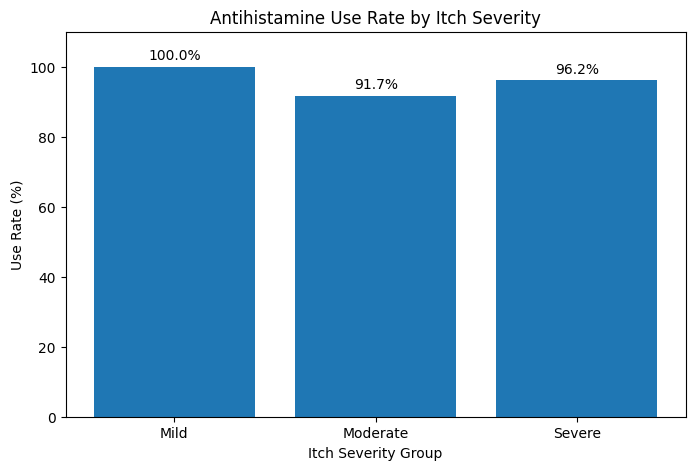

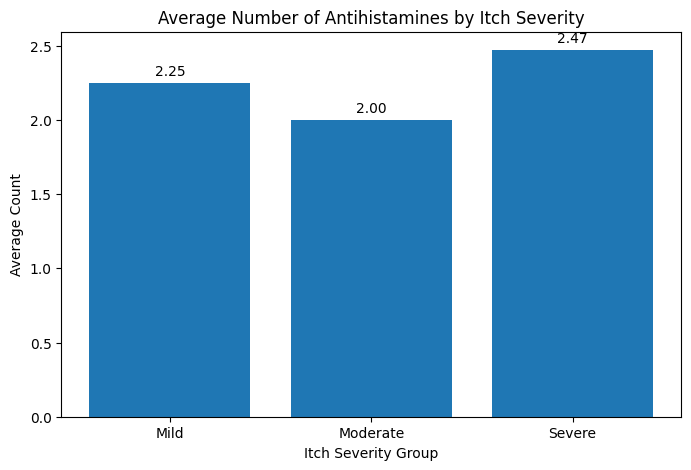

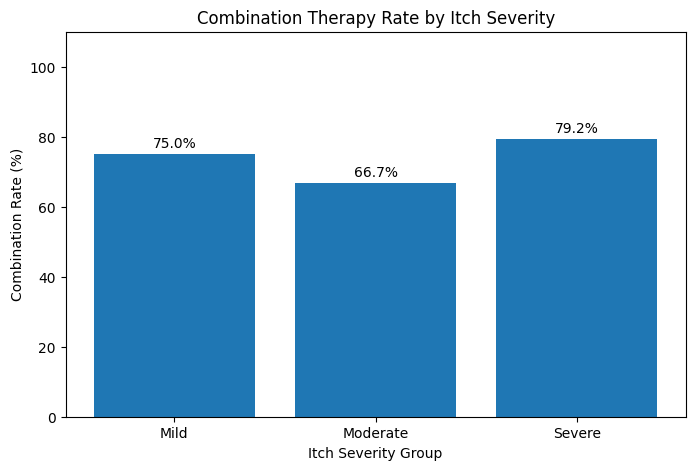

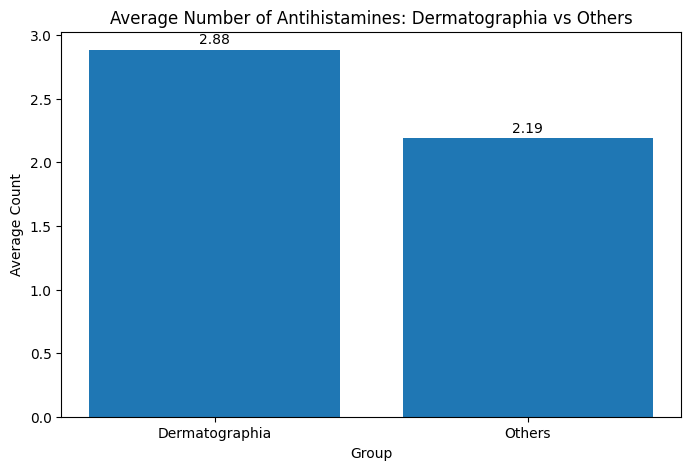

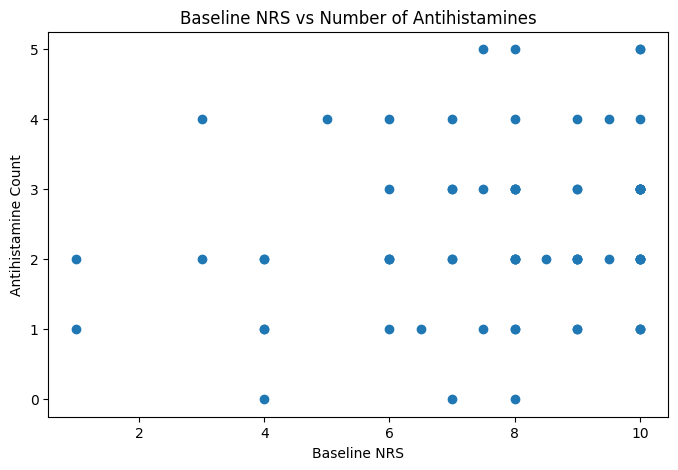


[Baseline NRS와 항히스타민제 개수 상관계수]
0.1994

[항히스타민제 개수별 평균 개선율]
   antihistamine_count  patient_count  mean_improvement_percent
0                    0              3                 83.333333
1                    1             14                 67.142857
2                    2             24                 73.250000
3                    3             17                 72.647059
4                    4              8                 78.125000
5                    5              4                 92.500000


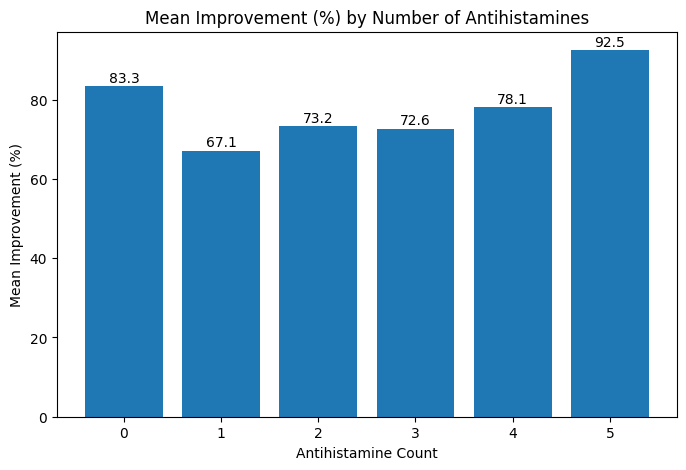

In [2]:

# ================================
# Google Colab용: 가려움 기반 약처방 분석 (최종 구조)
# 최종 구조:
# 1) 전체 데이터 정리
# 2) 가려움 정도별 항히스타민제 사용 패턴
# 3) 피부묘기증 vs 비피부묘기증 비교
# 4) 가려움 점수(NRS) vs 항히스타민제 개수
# 5) 항히스타민제 개수별 개선율 분석
# 6) 결과 저장
# ================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

# ----------------
# 0. 드라이브 마운트
# ----------------
drive.mount('/content/drive')

# ----------------
# 1. 데이터 불러오기
# ----------------
file_path = '/content/drive/MyDrive/Colab Notebooks/skin_project/SupplementaryTable1_MAR04.xlsx'
raw = pd.read_excel(file_path, header=None)

# ----------------
# 2. 헤더 및 본문 정리
# ----------------
columns = raw.iloc[2].tolist()
data = raw.iloc[3:].copy()
data.columns = columns

section = None
sensation = None
rows = []

for _, row in data.iterrows():
    first_val = str(row["Patient Number"]).strip()
    patient_num = pd.to_numeric(first_val, errors="coerce")

    if pd.isna(patient_num):
        if first_val.isupper():
            sensation = first_val
        else:
            section = first_val
        continue

    row_dict = row.to_dict()
    row_dict["diagnosis_group"] = section
    row_dict["sensation_group"] = sensation
    rows.append(row_dict)

df = pd.DataFrame(rows).reset_index(drop=True)

# ----------------
# 3. 숫자형 변환
# ----------------
df["Patient Number"] = pd.to_numeric(df["Patient Number"], errors="coerce")
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Follow up after first injection (days)"] = pd.to_numeric(
    df["Follow up after first injection (days)"], errors="coerce"
)

# ----------------
# 4. 주요 텍스트 컬럼 전처리
# ----------------
text_cols = [
    "Clinical presentation/ Duration of disease",
    "Topical meds/Light treamtent ",
    "Antihistamines/neuropathic meds",
    "Systemic antibiotics or anti-inflammatory meds",
    "Dosage (H = 60 mg, M = 30 mg)",
    "Itch response (NRS +/- % impt)",
    "Adverse reactions",
    "Notations on response",
    "Relevant concomitant medications",
    "Prediabetes (P), Diabetes Mellitus Type 2 (DM), Renal Insufficiency (RI)"
]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str)

# ----------------
# 5. NRS / 개선율 추출 함수
# ----------------
def extract_baseline_nrs(text):
    if pd.isna(text):
        return np.nan
    text = str(text)

    m = re.search(r"NRS\s*([0-9]+(?:\.[0-9]+)?)\s*(?:to|-)\s*([0-9]+(?:\.[0-9]+)?)", text, flags=re.I)
    if m:
        return float(m.group(1))

    m = re.search(r"Itch\s*NRS\s*([0-9]+(?:\.[0-9]+)?)\s*(?:to|-)\s*([0-9]+(?:\.[0-9]+)?)", text, flags=re.I)
    if m:
        return float(m.group(1))

    m = re.search(r"NRS\s*([0-9]+(?:\.[0-9]+)?)", text, flags=re.I)
    if m:
        return float(m.group(1))

    return np.nan

def extract_followup_nrs(text):
    if pd.isna(text):
        return np.nan
    text = str(text)

    m = re.search(r"NRS\s*([0-9]+(?:\.[0-9]+)?)\s*(?:to|-)\s*([0-9]+(?:\.[0-9]+)?)", text, flags=re.I)
    if m:
        return float(m.group(2))

    m = re.search(r"Itch\s*NRS\s*([0-9]+(?:\.[0-9]+)?)\s*(?:to|-)\s*([0-9]+(?:\.[0-9]+)?)", text, flags=re.I)
    if m:
        return float(m.group(2))

    return np.nan

def extract_improvement_percent(text):
    if pd.isna(text):
        return np.nan
    text = str(text)

    percents = re.findall(r"([0-9]+(?:\.[0-9]+)?)\s*%", text)
    if len(percents) > 0:
        return float(percents[0])

    # NRS 값이 둘 다 있으면 직접 개선율 계산
    baseline = extract_baseline_nrs(text)
    followup = extract_followup_nrs(text)
    if pd.notna(baseline) and pd.notna(followup) and baseline != 0:
        return ((baseline - followup) / baseline) * 100

    return np.nan

df["baseline_nrs"] = df["Itch response (NRS +/- % impt)"].apply(extract_baseline_nrs)
df["followup_nrs"] = df["Itch response (NRS +/- % impt)"].apply(extract_followup_nrs)
df["improvement_percent"] = df["Itch response (NRS +/- % impt)"].apply(extract_improvement_percent)

# ----------------
# 6. 가려움 정도 구간화
#    0~3: 경증 / 4~6: 중등도 / 7~10: 중증
# ----------------
def severity_group(nrs):
    if pd.isna(nrs):
        return np.nan
    if nrs <= 3:
        return "Mild"
    elif nrs <= 6:
        return "Moderate"
    else:
        return "Severe"

df["itch_severity_group"] = df["baseline_nrs"].apply(severity_group)

# ----------------
# 7. 항히스타민제 사용 여부 및 개수 계산
# ----------------
antihistamine_keywords = [
    "cetirizine", "levocetirizine", "fexofenadine", "loratadine", "lortatidine",
    "diphenhydramine", "hydroxyzine", "chlorpheniramine", "desloratadine",
    "rupatadine", "bilastine", "ebastine", "famotidine"
]

def count_antihistamines(text):
    if pd.isna(text):
        return 0
    text = str(text).lower()
    found = set()
    for drug in antihistamine_keywords:
        if drug in text:
            found.add(drug)
    return len(found)

df["antihistamine_count"] = df["Antihistamines/neuropathic meds"].apply(count_antihistamines)
df["antihistamine_use"] = (df["antihistamine_count"] > 0).astype(int)
df["multi_antihistamine_use"] = (df["antihistamine_count"] >= 2).astype(int)
df["high_intensity_antihistamine_use"] = (df["antihistamine_count"] >= 3).astype(int)

# ----------------
# 8. 피부묘기증 환자 subset
# ----------------
df["is_dermatographia"] = df["diagnosis_group"].str.contains("Dermatograph", case=False, na=False).astype(int)
df["diagnosis_binary"] = np.where(df["is_dermatographia"] == 1, "Dermatographia", "Others")
derm_df = df[df["is_dermatographia"] == 1].copy()
non_derm_df = df[df["is_dermatographia"] == 0].copy()

# ----------------
# 9. 전체 데이터 요약
# ----------------
print("\n[전체 데이터 크기]")
print(df.shape)

print("\n[진단 분포 상위 15개]")
print(df["diagnosis_group"].value_counts().head(15))

print("\n[가려움 정도 분포]")
print(df["itch_severity_group"].value_counts(dropna=False))

print("\n[항히스타민제 사용 여부]")
print(df["antihistamine_use"].value_counts())

print("\n[항히스타민제 개수 요약]")
print(df["antihistamine_count"].describe())

# ----------------
# 10. 가려움 정도별 약처방 패턴
# ----------------
severity_summary = (
    df.dropna(subset=["itch_severity_group"])
      .groupby("itch_severity_group")
      .agg(
          patient_count=("Patient Number", "count"),
          mean_baseline_nrs=("baseline_nrs", "mean"),
          antihistamine_use_rate=("antihistamine_use", "mean"),
          mean_antihistamine_count=("antihistamine_count", "mean"),
          multi_antihistamine_rate=("multi_antihistamine_use", "mean"),
          high_intensity_rate=("high_intensity_antihistamine_use", "mean")
      )
      .reset_index()
)

severity_order = ["Mild", "Moderate", "Severe"]
severity_summary["itch_severity_group"] = pd.Categorical(
    severity_summary["itch_severity_group"],
    categories=severity_order,
    ordered=True
)
severity_summary = severity_summary.sort_values("itch_severity_group")

print("\n[가려움 정도별 약처방 패턴 요약]")
print(severity_summary)

# ----------------
# 11. 피부묘기증 vs 비피부묘기증 비교
# ----------------
diagnosis_compare = (
    df.groupby("diagnosis_binary")
      .agg(
          patient_count=("Patient Number", "count"),
          mean_baseline_nrs=("baseline_nrs", "mean"),
          antihistamine_use_rate=("antihistamine_use", "mean"),
          mean_antihistamine_count=("antihistamine_count", "mean"),
          multi_antihistamine_rate=("multi_antihistamine_use", "mean"),
          mean_improvement_percent=("improvement_percent", "mean")
      )
      .reset_index()
)

print("\n[피부묘기증 vs 비피부묘기증 비교]")
print(diagnosis_compare)

# ----------------
# 12. 피부묘기증 환자만 따로 요약
# ----------------
if len(derm_df) > 0:
    derm_summary = (
        derm_df.dropna(subset=["itch_severity_group"])
               .groupby("itch_severity_group")
               .agg(
                   patient_count=("Patient Number", "count"),
                   mean_baseline_nrs=("baseline_nrs", "mean"),
                   antihistamine_use_rate=("antihistamine_use", "mean"),
                   mean_antihistamine_count=("antihistamine_count", "mean"),
                   multi_antihistamine_rate=("multi_antihistamine_use", "mean"),
                   mean_improvement_percent=("improvement_percent", "mean")
               )
               .reset_index()
    )

    derm_summary["itch_severity_group"] = pd.Categorical(
        derm_summary["itch_severity_group"],
        categories=severity_order,
        ordered=True
    )
    derm_summary = derm_summary.sort_values("itch_severity_group")

    print("\n[피부묘기증 환자 subset 요약]")
    print(derm_summary)
else:
    print("\n[피부묘기증 환자 subset] 해당 데이터 없음")

# ----------------
# 13. 시각화 1: 가려움 정도별 항히스타민제 사용률
# ----------------
plot_df = severity_summary.copy()
plot_df["antihistamine_use_rate_percent"] = plot_df["antihistamine_use_rate"] * 100
plot_df["multi_antihistamine_rate_percent"] = plot_df["multi_antihistamine_rate"] * 100
plot_df["high_intensity_rate_percent"] = plot_df["high_intensity_rate"] * 100

plt.figure(figsize=(8, 5))
plt.bar(plot_df["itch_severity_group"].astype(str), plot_df["antihistamine_use_rate_percent"])
plt.title("Antihistamine Use Rate by Itch Severity")
plt.xlabel("Itch Severity Group")
plt.ylabel("Use Rate (%)")
plt.ylim(0, 110)
for i, v in enumerate(plot_df["antihistamine_use_rate_percent"]):
    plt.text(i, v + 2, f"{v:.1f}%", ha="center")
plt.show()

# ----------------
# 14. 시각화 2: 가려움 정도별 평균 항히스타민제 개수
# ----------------
plt.figure(figsize=(8, 5))
plt.bar(plot_df["itch_severity_group"].astype(str), plot_df["mean_antihistamine_count"])
plt.title("Average Number of Antihistamines by Itch Severity")
plt.xlabel("Itch Severity Group")
plt.ylabel("Average Count")
for i, v in enumerate(plot_df["mean_antihistamine_count"]):
    plt.text(i, v + 0.05, f"{v:.2f}", ha="center")
plt.show()

# ----------------
# 15. 시각화 3: 가려움 정도별 병용 비율(2개 이상)
# ----------------
plt.figure(figsize=(8, 5))
plt.bar(plot_df["itch_severity_group"].astype(str), plot_df["multi_antihistamine_rate_percent"])
plt.title("Combination Therapy Rate by Itch Severity")
plt.xlabel("Itch Severity Group")
plt.ylabel("Combination Rate (%)")
plt.ylim(0, 110)
for i, v in enumerate(plot_df["multi_antihistamine_rate_percent"]):
    plt.text(i, v + 2, f"{v:.1f}%", ha="center")
plt.show()

# ----------------
# 16. 시각화 4: 피부묘기증 vs 비피부묘기증 평균 항히스타민제 개수 비교
# ----------------
compare_plot = diagnosis_compare.copy()
compare_plot["antihistamine_use_rate_percent"] = compare_plot["antihistamine_use_rate"] * 100
compare_plot["multi_antihistamine_rate_percent"] = compare_plot["multi_antihistamine_rate"] * 100

plt.figure(figsize=(8, 5))
plt.bar(compare_plot["diagnosis_binary"], compare_plot["mean_antihistamine_count"])
plt.title("Average Number of Antihistamines: Dermatographia vs Others")
plt.xlabel("Group")
plt.ylabel("Average Count")
for i, v in enumerate(compare_plot["mean_antihistamine_count"]):
    plt.text(i, v + 0.05, f"{v:.2f}", ha="center")
plt.show()

# ----------------
# 17. 시각화 5: NRS와 항히스타민제 개수의 관계
# ----------------
scatter_df = df.dropna(subset=["baseline_nrs", "antihistamine_count"]).copy()

plt.figure(figsize=(8, 5))
plt.scatter(scatter_df["baseline_nrs"], scatter_df["antihistamine_count"])
plt.title("Baseline NRS vs Number of Antihistamines")
plt.xlabel("Baseline NRS")
plt.ylabel("Antihistamine Count")
plt.show()

if len(scatter_df) >= 2:
    corr_val = scatter_df["baseline_nrs"].corr(scatter_df["antihistamine_count"])
    print("\n[Baseline NRS와 항히스타민제 개수 상관계수]")
    print(round(corr_val, 4))

# ----------------
# 18. 시각화 6: 항히스타민제 개수별 평균 개선율
# ----------------
improvement_df = (
    df.dropna(subset=["improvement_percent"])
      .groupby("antihistamine_count")
      .agg(
          patient_count=("Patient Number", "count"),
          mean_improvement_percent=("improvement_percent", "mean")
      )
      .reset_index()
      .sort_values("antihistamine_count")
)

print("\n[항히스타민제 개수별 평균 개선율]")
print(improvement_df)

if len(improvement_df) > 0:
    plt.figure(figsize=(8, 5))
    plt.bar(improvement_df["antihistamine_count"].astype(str), improvement_df["mean_improvement_percent"])
    plt.title("Mean Improvement (%) by Number of Antihistamines")
    plt.xlabel("Antihistamine Count")
    plt.ylabel("Mean Improvement (%)")
    for i, v in enumerate(improvement_df["mean_improvement_percent"]):
        plt.text(i, v + 1, f"{v:.1f}", ha="center")
    plt.show()





/tmp/ipykernel_3800/3222279108.py:125: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3800/3222279108.py:125: UserWarning: Glyph 46021 (\N{HANGUL SYLLABLE DOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3800/3222279108.py:125: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3800/3222279108.py:125: UserWarning: Glyph 48277 (\N{HANGUL SYLLABLE BEOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3800/3222279108.py:125: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3800/3222279108.py:125: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3800/3222279108.py:125: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.t

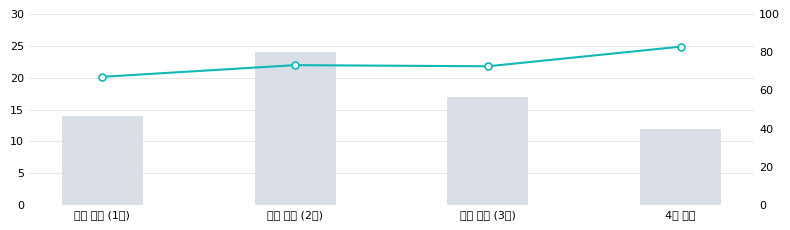

In [10]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
font_path = fm.findfont("NanumGothic")
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False


# 엑셀 불러오기
file_path = '/content/drive/MyDrive/Colab Notebooks/skin_project/SupplementaryTable1_MAR04.xlsx'
raw = pd.read_excel(file_path, header=None)

# 데이터 정리
columns = raw.iloc[2].tolist()
data = raw.iloc[3:].copy()
data.columns = columns

section = None
sensation = None
rows = []

for _, row in data.iterrows():
    first_val = str(row["Patient Number"]).strip()
    patient_num = pd.to_numeric(first_val, errors="coerce")

    if pd.isna(patient_num):
        if first_val.isupper():
            sensation = first_val
        else:
            section = first_val
        continue

    row_dict = row.to_dict()
    row_dict["diagnosis_group"] = section
    row_dict["sensation_group"] = sensation
    rows.append(row_dict)

df = pd.DataFrame(rows).reset_index(drop=True)

# 문자열 처리
df["Antihistamines/neuropathic meds"] = df["Antihistamines/neuropathic meds"].fillna("").astype(str)
df["Itch response (NRS +/- % impt)"] = df["Itch response (NRS +/- % impt)"].fillna("").astype(str)

# 개선율 추출
def extract_improvement(text):
    text = str(text)
    perc = re.findall(r"([0-9]+(?:\.[0-9]+)?)\s*%", text)
    if perc:
        return float(perc[0])

    m = re.search(r"NRS\s*(\d+)\s*(?:to|-)\s*(\d+)", text)
    if m:
        b, f = float(m.group(1)), float(m.group(2))
        if b != 0:
            return ((b - f) / b) * 100
    return np.nan

df["improvement_percent"] = df["Itch response (NRS +/- % impt)"].apply(extract_improvement)

# 항히스타민 개수
keywords = [
    "cetirizine","levocetirizine","fexofenadine","loratadine",
    "diphenhydramine","hydroxyzine","chlorpheniramine",
    "desloratadine","rupatadine","bilastine","ebastine","famotidine"
]

def count_meds(text):
    text = str(text).lower()
    return len({k for k in keywords if k in text})

df["antihistamine_count"] = df["Antihistamines/neuropathic meds"].apply(count_meds)

# 그룹화
df = df.dropna(subset=["improvement_percent"])
df = df[df["antihistamine_count"] >= 1]

def group(x):
    if x == 1: return "단독 요법 (1개)"
    elif x == 2: return "이중 요법 (2개)"
    elif x == 3: return "다중 요법 (3개)"
    else: return "4개 이상"

df["group"] = df["antihistamine_count"].apply(group)

plot_df = df.groupby("group").agg(
    patient_count=("Patient Number","count"),
    mean_improvement=("improvement_percent","mean")
).reset_index()

order = ["단독 요법 (1개)","이중 요법 (2개)","다중 요법 (3개)","4개 이상"]
plot_df["group"] = pd.Categorical(plot_df["group"], categories=order, ordered=True)
plot_df = plot_df.sort_values("group").set_index("group").reindex(order).fillna(0).reset_index()

# 그래프
x = np.arange(len(plot_df))
fig, ax1 = plt.subplots(figsize=(8,2.4))

ax1.bar(x, plot_df["patient_count"], width=0.42, color="#d9dee7")
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df["group"], fontsize=8)
ax1.set_ylim(0,30)
ax1.set_yticks(np.arange(0,31,5))
ax1.tick_params(length=0, labelsize=8)

ax2 = ax1.twinx()
ax2.plot(x, plot_df["mean_improvement"], color="#11b8b5",
         marker="o", markersize=5, linewidth=1.5,
         markerfacecolor="white", markeredgewidth=1.2)
ax2.set_ylim(0,100)
ax2.set_yticks(np.arange(0,101,20))
ax2.tick_params(length=0, labelsize=8)

for s in ["top","right","left","bottom"]:
    ax1.spines[s].set_visible(False)
    ax2.spines[s].set_visible(False)

ax1.grid(axis="y", color="#e5e7eb", linewidth=0.8)
ax1.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
import numpy as np
import re

# =========================
# 1. 엑셀 불러오기
# =========================
file_path = '/content/drive/MyDrive/Colab Notebooks/skin_project/SupplementaryTable1_MAR04.xlsx'   # 파일명 확인
raw = pd.read_excel(file_path, header=None)

# 헤더 행 찾기
header_row_idx = raw[raw.iloc[:, 0].astype(str).str.contains("Patient Number", na=False)].index[0]
headers = raw.iloc[header_row_idx].tolist()

df = raw.iloc[header_row_idx + 1:].copy()
df.columns = headers
df = df.reset_index(drop=True)

# =========================
# 2. Diagnosis 붙이기
# =========================
current_diag = None
diagnosis_list = []

for _, row in df.iterrows():
    first_val = row["Patient Number"]
    non_null_count = row.notna().sum()

    # 진단명만 적혀 있는 행 찾기
    if isinstance(first_val, str) and non_null_count == 1:
        text = first_val.strip()

        if text not in ["ITCHING (PRIMARY SENSATION)", "BURNING (PRIMARY SENSATION)"]:
            current_diag = text
        diagnosis_list.append(np.nan)
    else:
        diagnosis_list.append(current_diag)

df["Diagnosis"] = diagnosis_list

# 실제 환자 행만 남기기
df = df[pd.to_numeric(df["Patient Number"], errors="coerce").notna()].copy()

# =========================
# 3. baseline NRS 추출
# =========================
def extract_baseline_nrs(text):
    if pd.isna(text):
        return np.nan

    text = str(text)

    m = re.search(r'NRS\s*(\d+(?:\.\d+)?)\s*to\s*(\d+(?:\.\d+)?)', text, flags=re.I)
    if m:
        return float(m.group(1))

    m = re.search(r'NRS\s*(\d+(?:\.\d+)?)', text, flags=re.I)
    if m:
        return float(m.group(1))

    return np.nan

df["baseline_nrs"] = df["Itch response (NRS +/- % impt)"].apply(extract_baseline_nrs)

# =========================
# 4. Mild / Moderate / Severe 분류
# =========================
def severity_group(nrs):
    if pd.isna(nrs):
        return np.nan
    elif nrs <= 3:
        return "Mild"
    elif nrs <= 6:
        return "Moderate"
    else:
        return "Severe"

df["severity_group"] = df["baseline_nrs"].apply(severity_group)

# =========================
# 5. 약 개수 세기
# 기준 열: Antihistamines/neuropathic meds
# =========================
def count_drugs(text):
    if pd.isna(text):
        return 0

    text = str(text).strip()

    if text == "" or text.lower() == "none":
        return 0

    # 쉼표 기준으로 약 개수 세기
    items = [x.strip() for x in text.split(",") if x.strip()]
    return len(items)

df["drug_count"] = df["Antihistamines/neuropathic meds"].apply(count_drugs)

# =========================
# 6. 그룹별 숫자 출력 함수
# =========================
def print_group_stats(name, data):
    n = len(data)
    mean_drugs = data["drug_count"].mean()
    combo_rate = (data["drug_count"] >= 2).mean() * 100
    high_rate = (data["drug_count"] >= 3).mean() * 100

    print(f"[{name}]")
    print(f"환자 수: {n}")
    print(f"평균 약물 수: {mean_drugs:.1f}")
    print(f"병용 처방 비율(>=2개): {combo_rate:.1f}%")
    print(f"고강도 처방 비율(>=3개): {high_rate:.1f}%")
    print()

# =========================
# 7. Mild / Moderate / Severe 출력
# =========================
for group in ["Mild", "Moderate", "Severe"]:
    group_df = df[df["severity_group"] == group]
    print_group_stats(group, group_df)

# =========================
# 8. 피부묘기증(Dermatographism) 출력
# =========================
derm_df = df[df["Diagnosis"].astype(str).str.contains("Dermatograph", case=False, na=False)]
print_group_stats("피부묘기증 (Dermatographism)", derm_df)

[Mild]
환자 수: 4
평균 약물 수: 3.2
병용 처방 비율(>=2개): 100.0%
고강도 처방 비율(>=3개): 75.0%

[Moderate]
환자 수: 12
평균 약물 수: 4.9
병용 처방 비율(>=2개): 100.0%
고강도 처방 비율(>=3개): 91.7%

[Severe]
환자 수: 53
평균 약물 수: 4.1
병용 처방 비율(>=2개): 94.3%
고강도 처방 비율(>=3개): 77.4%

[피부묘기증 (Dermatographism)]
환자 수: 17
평균 약물 수: 4.8
병용 처방 비율(>=2개): 100.0%
고강도 처방 비율(>=3개): 88.2%



In [4]:
print("\n[severity_summary 최종 숫자 확인]")
print(severity_summary[[
    "itch_severity_group",
    "patient_count",
    "mean_antihistamine_count",
    "multi_antihistamine_rate",
    "high_intensity_rate"
]])

print("\n[diagnosis_compare 최종 숫자 확인]")
print(diagnosis_compare[[
    "diagnosis_binary",
    "patient_count",
    "mean_antihistamine_count",
    "multi_antihistamine_rate",
    "mean_improvement_percent"
]])


[severity_summary 최종 숫자 확인]
  itch_severity_group  patient_count  mean_antihistamine_count  \
0                Mild              4                  2.250000   
1            Moderate             12                  2.000000   
2              Severe             53                  2.471698   

   multi_antihistamine_rate  high_intensity_rate  
0                  0.750000             0.250000  
1                  0.666667             0.250000  
2                  0.792453             0.471698  

[diagnosis_compare 최종 숫자 확인]
  diagnosis_binary  patient_count  mean_antihistamine_count  \
0   Dermatographia             17                  2.882353   
1           Others             53                  2.188679   

   multi_antihistamine_rate  mean_improvement_percent  
0                  1.000000                 74.705882  
1                  0.679245                 73.735849  
